In [ ]:
!python3 -m spacy download en_core_web_sm
!pip install sentencepiece
!pip install tf-keras
!pip install tf-keras

In [101]:
import pandas as pd
import numpy as np
import spacy
from textstat import textstat
import textstat as ts_module
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, logging
import os
from datasets import load_dataset, load_from_disk
import nltk
import ssl
import torch
from bert_score import score as bert_score
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import warnings

In [3]:
LOCAL_WIKIAUTO_PATH = 'auto_acl.csv'
SUBTLEX_FILE_PATH = "SUBTLEX-UK.csv"

MODEL_CHECKPOINT = "t5-small"
MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 128

In [4]:
# Source - https://stackoverflow.com/a
# Posted by fstang, modified by community. See post 'Timeline' for change history
# Retrieved 2025-12-02, License - CC BY-SA 4.0
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download()


showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [4]:
try:
    nltk.download('cmudict', quiet=True)
except Exception as e:
    print("Warning: NLTK download failed,",e, ". Syllable count may default to estimate.")


In [5]:
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Spacy model not found. Downloading...")
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

In [33]:
class AdaptiReadPreprocessor:
    def __init__(self):
        self.word_freq_dict = {}
        self.tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
        self.load_frequency_data()

    def load_frequency_data(self):
        if os.path.exists(SUBTLEX_FILE_PATH):
            df = pd.read_csv(SUBTLEX_FILE_PATH, sep=';',on_bad_lines='skip', low_memory=False)
            if 'Spelling' in df.columns and 'LogFreq(Zipf)' in df.columns:
                self.word_freq_dict = dict(zip(df['Spelling'].astype(str).str.lower(), pd.to_numeric(df['LogFreq(Zipf)'], errors='coerce').fillna(0.0)))
            else:
                print("Columns 'Spelling' or 'LogFreq(Zipf)' not found in SUBTLEX.")

    def get_word_rarity(self, w):
        freq = self.word_freq_dict.get(w.lower(), 0.0)
        return 8.0 - freq if freq > 0 else 8.0

    def calculate_dsci(self, text):
        doc = nlp(text)
        total_rarity_score = 0.0
        word_count = 0

        for token in doc:
            if token.is_alpha and not token.is_stop:
                word_count += 1
                rarity = self.get_word_rarity(token.text)
                syllables = ts_module.textstat.syllable_count(token.text)
                word_complexity = rarity + (syllables * 1.5)
                total_rarity_score += word_complexity
        if word_count == 0:
            return 0.0
        d_sci_score = total_rarity_score / word_count
        return d_sci_score

    def preprocess_function(self, examples):
        inputs = ["simplify: " + str(doc) for doc in examples["complex_sentence"]]
        simple_sentences = []
        for doc in examples["simple_sentence"]:
            if isinstance(doc, bytes):
                simple_sentences.append(doc.decode("utf-8", errors="ignore"))
            else:
                simple_sentences.append(str(doc))
        model_inputs = self.tokenizer(inputs, max_length=MAX_INPUT_LENGTH, truncation=True)
        labels = self.tokenizer(text_target=simple_sentences, max_length=MAX_TARGET_LENGTH, truncation=True)
        model_inputs["labels"] = labels["input_ids"]
        model_inputs["d_sci_score"] = [self.calculate_dsci(str(doc)) for doc in examples["complex_sentence"]]
        return model_inputs

In [34]:
processor = AdaptiReadPreprocessor()

In [71]:
df_dictionary = pd.read_csv('SUBTLEX-UK.csv', sep=';', low_memory=False)
df_dictionary.head()

,Spelling,FreqCount,Cbeebies_freq,CBBC_freq,BNC_freq,LogFreq(Zipf),LogFreqCbeebies(Zipf),LogFreqCBBC(Zipf),LogFreqBNC(Zipf),CD_count,...,DomPoSFreq,DomPoSLemmaTotalFreq,AllPoS,AllPoSFreq,CapitFreq,Spell_check,Hyphen,Homophonic_entry,Double_word_entry,Freq_double_entry
0,labour,45591.0,1.0,81.0,27108.0,"5,35","2,53","3,78","5,43",8196.0,...,40420.0,40420.0,.name.noun.adjective.verb.unclassified.,.40420.4240.631.284.16.,41050.0,UK,0.0,NaN,NaN,NaN
1,programme,31950.0,42.0,731.0,19071.0,"5,20","3,86","4,73","5,28",15482.0,...,30786.0,35165.0,.noun.name.verb.adjective.adverb.unclassified.,.30786.458.440.246.11.9.,459.0,UK,0.0,"program, programme",NaN,NaN
2,favourite,27052.0,2015.0,3481.0,4769.0,"5,13","5,54","5,41","4,68",13805.0,...,16964.0,16964.0,.adjective.noun.name.verb.unclassified.,.16964.9727.268.92.1.,308.0,UK,0.0,NaN,NaN,NaN
3,colour,22651.0,1665.0,1789.0,11541.0,"5,05","5,45","5,12","5,06",10120.0,...,20686.0,30119.0,.noun.verb.name.adjective.unclassified.adverb.,.20686.1107.622.230.3.3.,622.0,UK,0.0,"color, colour",NaN,NaN
4,realise,15715.0,117.0,910.0,3904.0,"4,89","4,30","4,82","4,59",11118.0,...,15112.0,27226.0,.verb.noun.name.adjective.,.15112.577.18.8.,25.0,UK,0.0,"realise, realize(2)",NaN,NaN


In [64]:
dataset = None
if os.path.exists(LOCAL_WIKIAUTO_PATH):
    file_ext = LOCAL_WIKIAUTO_PATH.split('.')[-1]
    if file_ext == 'csv':
        dataset = load_dataset('csv', data_files=LOCAL_WIKIAUTO_PATH, split='train')
    else:
        print(f"Unsupported file extension: {file_ext}")

In [65]:
if 'normal_sentence' in dataset.column_names:
    dataset = dataset.rename_column("normal_sentence", "complex_sentence")

In [67]:
df= pd.DataFrame(dataset)
df.head()

,complex_sentence,simple_sentence
0,"b'It involved the McLaren team , the Ferrari t...",b'Then it was claimed that Renault F1 had info...
1,"b'The Lucario in the movie , voiced in English...","b'The Lucario in the movie , can also speak hu..."
2,b'A Professor Emeritus of the Institute of Arc...,b'He was Professor Emeritus in the University ...
3,"b'On October 11 , 2017 , President Donald Trum...","b'On October 11 , 2017 , President Donald Trum..."
4,b'This term strongly suggests natural selectio...,"b""Spencer 's term does strongly suggest natura..."


In [37]:
tokenized_datasets = dataset.map(
        processor.preprocess_function,
        batched=True,
        batch_size=16
    )
print("Sample D-SCI Score:", tokenized_datasets[0]['d_sci_score'])

Map: 100%|██████████| 468137/468137 [41:35<00:00, 187.63 examples/s]

Sample D-SCI Score: 10.785714285714286


In [ ]:
save_path = "./tokenizer_t5_model"
tokenized_datasets.save_to_disk(save_path)

Saving the dataset (1/1 shards): 100%|██████████| 468137/468137 [00:00<00:00, 1586889.28 examples/s]


In [ ]:
dataset = load_from_disk('tokenizer_t5_model')

In [69]:
df_tokenized = pd.DataFrame(dataset)
df_tokenized.head()

,complex_sentence,simple_sentence,input_ids,attention_mask,labels,d_sci_score
0,"b'It involved the McLaren team , the Ferrari t...",b'Then it was claimed that Renault F1 had info...,"[18356, 10, 3, 115, 31, 196, 17, 1381, 8, 3038...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 115, 31, 634, 29, 34, 47, 7760, 24, 20493,...",10.785714
1,"b'The Lucario in the movie , voiced in English...","b'The Lucario in the movie , can also speak hu...","[18356, 10, 3, 115, 31, 634, 3, 11748, 14414, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 115, 31, 634, 3, 11748, 14414, 16, 8, 1974...",11.000000
2,b'A Professor Emeritus of the Institute of Arc...,b'He was Professor Emeritus in the University ...,"[18356, 10, 3, 115, 31, 188, 5589, 3967, 49, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 115, 31, 3845, 47, 5589, 3967, 49, 155, 30...",13.250000
3,"b'On October 11 , 2017 , President Donald Trum...","b'On October 11 , 2017 , President Donald Trum...","[18356, 10, 3, 115, 31, 7638, 1797, 850, 3, 6,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 115, 31, 7638, 1797, 850, 3, 6, 1233, 3, 6...",11.705882
4,b'This term strongly suggests natural selectio...,"b""Spencer 's term does strongly suggest natura...","[18356, 10, 3, 115, 31, 3713, 1657, 7157, 6490...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[3, 115, 121, 134, 3208, 2110, 3, 31, 7, 1657,...",11.692308


In [75]:
df_tokenized['d_sci_score']

,d_sci_score
count,468137.000000
mean,10.472935
std,2.795186
min,0.000000
25%,10.673913
50%,11.093750
75%,11.500000
max,17.000000


In [40]:
split = dataset.train_test_split(test_size=0.2)

In [42]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, legacy=False)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

In [43]:
BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 2e-5

In [44]:
training_args = Seq2SeqTrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        weight_decay=0.01,
        save_total_limit=2,
        num_train_epochs=EPOCHS,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        logging_steps=100,
        push_to_hub=False,
    )

In [45]:
trainer = Seq2SeqTrainer(
        model=model,
        args=training_args,
        train_dataset=split['train'],
        eval_dataset=split['test'],
        tokenizer=tokenizer,
        data_collator=data_collator,
    )

/var/folders/77/xx208fvd4mg8hdlcsc5d4tf40000gn/T/ipykernel_30367/1598267631.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [46]:
trainer.train()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,1.014700,0.933137
2,0.958200,0.916678
3,0.951100,0.911187


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=140442, training_loss=1.0105056328101985, metrics={'train_runtime': 53510.8615, 'train_samples_per_second': 20.996, 'train_steps_per_second': 2.625, 'total_flos': 2.6120518042681344e+16, 'train_loss': 1.0105056328101985, 'epoch': 3.0})

In [82]:
OUTPUT_DIR = "./adaptiread_model_final"

In [83]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

('./adaptiread_model_final/tokenizer_config.json',
 './adaptiread_model_final/special_tokens_map.json',
 './adaptiread_model_final/spiece.model',
 './adaptiread_model_final/added_tokens.json',
 './adaptiread_model_final/tokenizer.json')

In [85]:
MODEL_PATH = "./adaptiread_model_final"
DEVICE = "cpu"

In [86]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)
model.to(DEVICE)

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=512, bias=False)
              (k): Linear(in_features=512, out_features=512, bias=False)
              (v): Linear(in_features=512, out_features=512, bias=False)
              (o): Linear(in_features=512, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 8)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=512, out_features=2048, bias=False)
              (wo): Linear(in_features=2048, out_features=512, bias=False)
              (dropout): Drop

In [87]:
model_processor = AdaptiReadPreprocessor()

In [ ]:
complex_text = "Text difficulty was operationalized through a composite index combining mean sentence length, proportion of low-frequency academic vocabulary, and a standardized readability score, each rescaled to a common metric before aggregation"
print("Original Input:", complex_text)


Original Input: Text difficulty was operationalized through a composite index combining mean sentence length, proportion of low-frequency academic vocabulary, and a standardized readability score, each rescaled to a common metric before aggregation


In [112]:
dsci_score_test = model_processor.calculate_dsci(complex_text)
print("Testing complex text:", complex_text)
print("Test complex_text-Dsci_Score:", dsci_score_test)

Testing complex text: Text difficulty was operationalized through a composite index combining mean sentence length, proportion of low-frequency academic vocabulary, and a standardized readability score, each rescaled to a common metric before aggregation
Test complex_text-Dsci_Score: 12.0


In [90]:
DSCI_THRESHOLD = 11.0

In [98]:
def predictor(texts):
    probs = []
    target_ids = tokenizer(text_target=simple_text, return_tensors="pt").input_ids.to(DEVICE)

    for text in texts:
        if not text.strip():
            probs.append(0.0)
            continue
        inp = tokenizer("simplify: " + text, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = model(input_ids=inp.input_ids, labels=target_ids)
            loss = outputs.loss.item()
            prob = np.exp(-loss)
            probs.append(prob)
    return np.array([[1-p, p] for p in probs])

In [ ]:
def simplify_test_complex_text(complex_text):
    inputs = tokenizer("simplify: " + complex_text, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
            outputs = model.generate(
                inputs["input_ids"],
                max_length=128,
                do_sample=True,         
                temperature=0.9,        
                top_p=0.95,             
                repetition_penalty=1.15, # Penalize repeating words (discourages copying)
            )
    simple_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return simple_text

In [ ]:
def semantic_analysis(simple_text, complex_text):
    with warnings.catch_warnings(): # added to remove unwanted display of warnings in outputs
        warnings.simplefilter("ignore")
        Precision, Recall, F1_score = bert_score([simple_text], [complex_text], lang="en", verbose=False)
    return F1_score.item()

Original Input: Text difficulty was operationalized through a composite index combining mean sentence length, proportion of low-frequency academic vocabulary, and a standardized readability score, each rescaled to a common metric before aggregation
Simplified Output: standardized readability score was rescaled to a common metric before aggregation.n'
BERT Score: 0.8946747779846191
Meaning is preserved.
Top 10 Words Influencing the Simplification:
1. 'readability' (Impact: 0.0649)
2. 'metric' (Impact: 0.0512)
3. 'score' (Impact: 0.0510)
4. 'before' (Impact: 0.0506)
5. 'standardized' (Impact: 0.0422)
6. 'rescaled' (Impact: 0.0414)
7. 'aggregation' (Impact: 0.0412)
8. 'common' (Impact: 0.0369)
9. 'to' (Impact: 0.0290)
10. 'difficulty' (Impact: 0.0283)


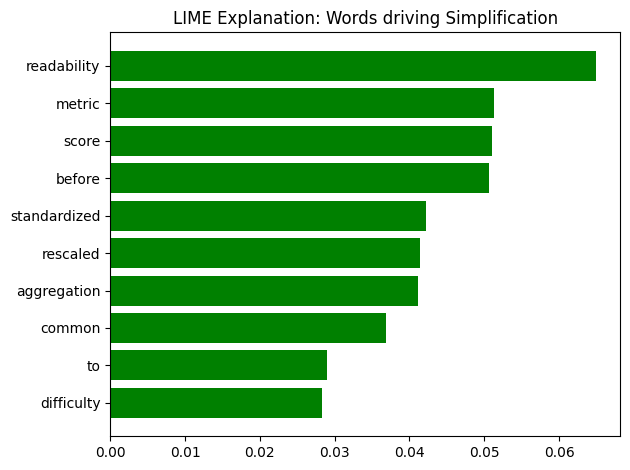

In [ ]:
logging.set_verbosity_error() # added to remove unwanted display of warnings in outputs
if dsci_score_test < DSCI_THRESHOLD:
    print("The sentence is simple and does not need to be simplified.")
else:
    print(f"Original Input: {complex_text}")
    simple_text = simplify_test_complex_text(complex_text)
    print(f"Simplified Output: {simple_text}")
    # Semantic Analysis
    bert_score_val = semantic_analysis(simple_text, complex_text)
    print(f"BERT Score: {bert_score_val}")
    if bert_score_val < 0.85:
        print("Meaning Drift Detected! Score is below 0.85.")
        while bert_score_val < 0.85:
            simple_text = simplify_test_complex_text(complex_text)
            bert_score_val = semantic_analysis(simple_text, complex_text)
            print(f"BERT Score: {bert_score_val}")
            if bert_score_val < 0.85:
                print("Meaning Drift Detected! Score is below 0.85.")
            else:
                print("Meaning is preserved.")
    else:
        print("Meaning is preserved.")

    # LIME Explainer
    explainer = LimeTextExplainer(class_names=["Irrelevant", "Relevant"])
    with warnings.catch_warnings(): # added to remove unwanted display of warnings in outputs
        warnings.simplefilter("ignore")
        exp = explainer.explain_instance(complex_text, predictor, num_features=10, num_samples=200)
    weights = exp.as_list()
    weights.sort(key=lambda x: abs(x[1]), reverse=True)
    print("Top 10 Words Influencing the Simplification:")
    for i, (word, weight) in enumerate(weights[:10]):
        print(f"{i+1}. '{word}' (Impact: {weight:.4f})")
    fig = exp.as_pyplot_figure()
    plt.title("LIME Explanation: Words driving Simplification")
    plt.tight_layout()